In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

df = pd.read_csv('../data/netflix-data.csv')

In [42]:
# Limpieza
df = df[~df['rating'].str.contains('min|Season', na=False)]

df['date_added'] = pd.to_datetime(df['date_added'].str.strip(), errors='coerce')
df['year_added'] = df['date_added'].dt.year

# Separacion
paises_separados = df['country'].str.split(', ').explode()
generos_separados = df['listed_in'].str.split(', ').explode()

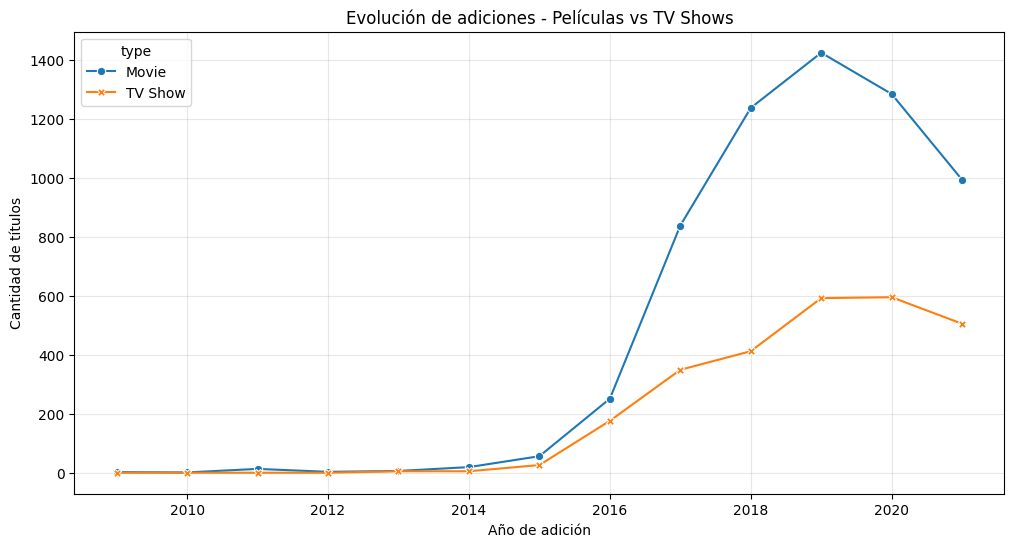

In [43]:
# Filtramos años recientes
trend_data = df[df['year_added'] > 2008].groupby(['year_added', 'type']).size().unstack()
trend_data = trend_data.fillna(0).astype(int)

# Graficamos
plt.figure(figsize=(12, 6))

sns.lineplot(data=trend_data, markers=True, dashes=False)

plt.title('Evolución de adiciones - Películas vs TV Shows')
plt.xlabel('Año de adición')
plt.ylabel('Cantidad de títulos')
plt.grid(True, alpha=0.3)

plt.show()

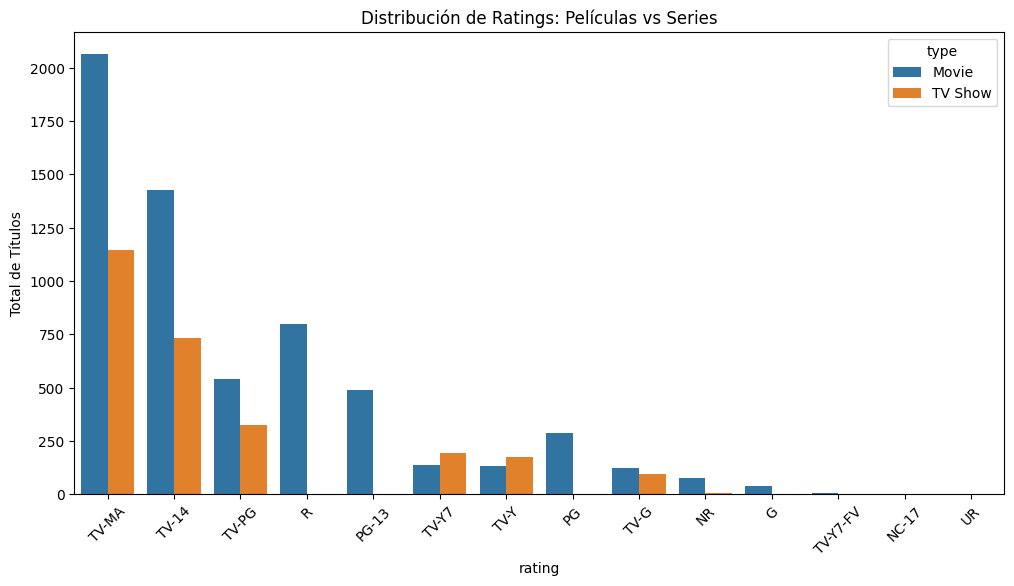

In [44]:
# Agrupamos por Rating y Tipo para ver la distribución
plt.figure(figsize=(12,6))
order_figure = df['rating'].value_counts().index # Ordenamos

sns.countplot(data=df, x='rating', hue='type', order=order_figure)

plt.title('Distribución de Ratings: Películas vs Series')
plt.xticks(rotation=45)
plt.ylabel('Total de Títulos')

plt.show()

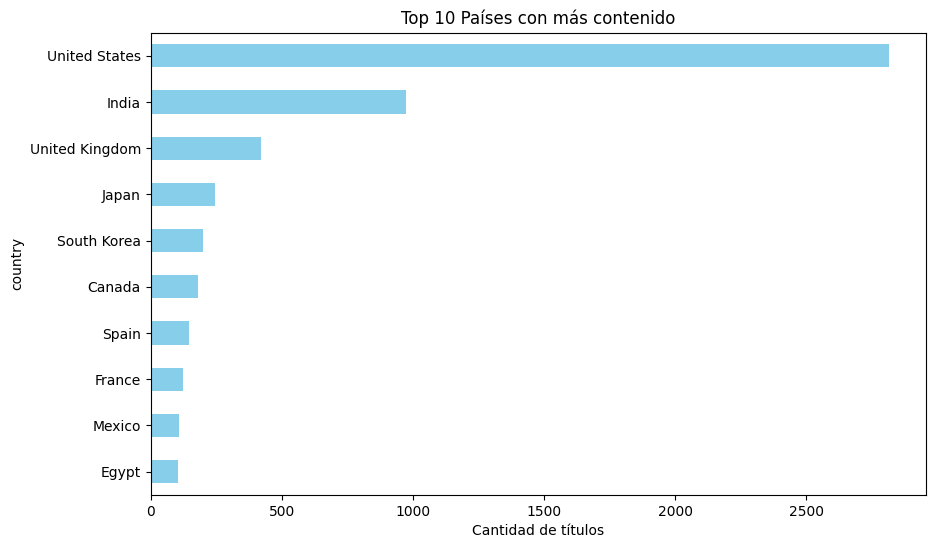

In [45]:
# Filtramos top 10 paises
top_countries = df['country'].value_counts().head(10)

plt.figure(figsize=(10, 6))

top_countries.plot(kind='barh', color='skyblue')

plt.gca().invert_yaxis()
plt.title('Top 10 Países con más contenido')
plt.xlabel('Cantidad de títulos')

plt.show()

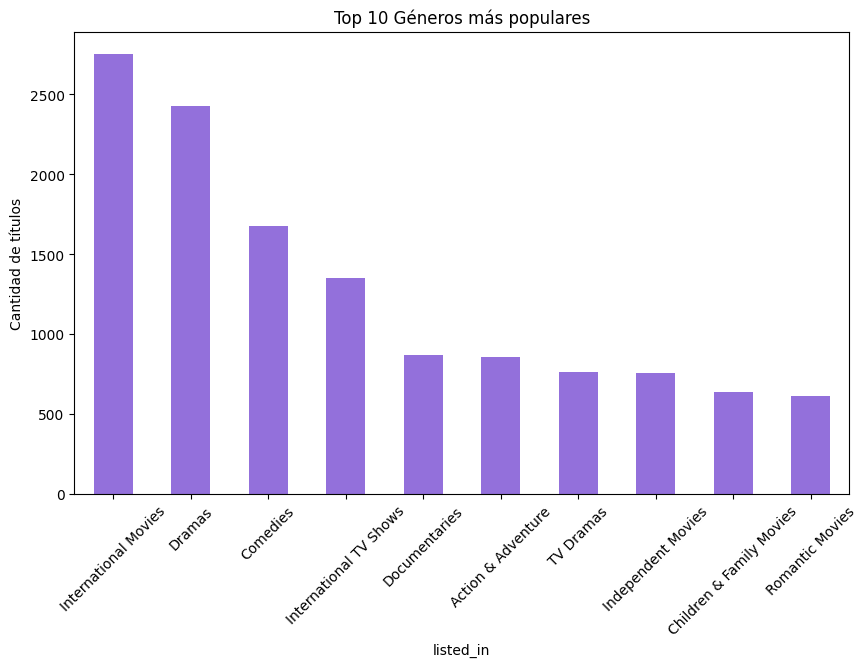

In [46]:
# Filtramos
top_generos = generos_separados.value_counts().head(10)

# Graficamos
plt.figure(figsize=(10, 6))

top_generos.plot(kind='bar', color='mediumpurple')

plt.title('Top 10 Géneros más populares')
plt.ylabel('Cantidad de títulos')
plt.xticks(rotation=45)

plt.show()